<a href="https://colab.research.google.com/github/pedrocovisi/dados_e_decisoes/blob/main/dados_e_decisoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Lucca Teodoro Vaz; Número USP: 18119311

---


Nome: Pedro Henrique de Oliveira Covisi; Número USP:  

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
url = 'https://raw.githubusercontent.com/cibelerusso/Datasets/main/DadoseDecisoes.csv'
df = pd.read_csv(url, decimal='.')

In [149]:
df.head()

,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não


# Item a
(a) Inicialmente, classifique os funcionários em dois grupos (Produtividade bin: ”Alta”ou ”Baixa”):

• Alta produtividade: funcionários com produtividade acima da mediana;

• Baixa produtividade: funcionários com produtividade abaixo ou igual à mediana.

In [150]:
median_prod = df['Produtividade'].median()
print(median_prod)

def classificar_produtividade(Produtividade):
    if Produtividade > median_prod:
        return "Alta"
    elif Produtividade < median_prod:
        return "Baixa"

df['Produtividade_bin'] = df['Produtividade'].apply(classificar_produtividade)

df.head()


87.04


,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office,Produtividade_bin
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não,Baixa
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim,Alta
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim,Alta
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim,Alta
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não,Baixa


# Item b
(b) Identifique o tipo (quantitativa discreta, quantitativa contínua ou qualitativa nominal ou ordinal) de cada variável do conjunto de dados

## Variaveis:
- Idade: Quantitativa Contínua
- Gênero: Qualitativa Nominal
- Departamento: Qualitativa Nominal
- Salário: Quantitativa Contínua
- Horas Trabalhadas: Quantitativa Contínua
- Produtividade: Quantitativa Contínua
- Satisfação:Quantitativa Contínua
- Tempo de Empresa: Quantitativa Contínua
- Cursos Realizados: Quantitativa Discreta
- Home Office: Qualitativa Nominal
- Produtividade(bin): Qualitativa Ordinal


# Item c
(c) Para analisar variáveis qualitativas, utilize tabelas de frequência, gráficos de barras ou gráficos de setores;


## Análise da distribuição de Funcionários por Departamento


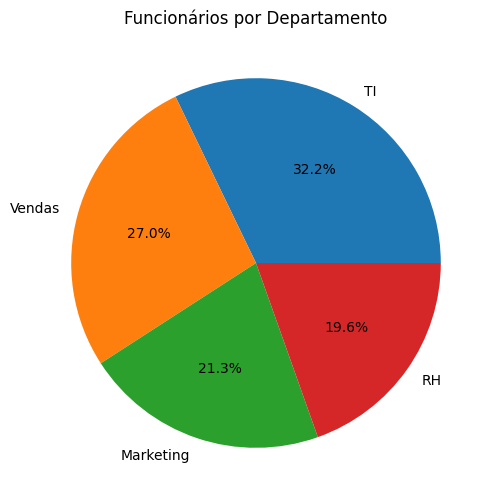

In [151]:
plt.figure(figsize=(8,6))
department_counts = df['Departamento'].value_counts()
plt.pie( ## Define gráfico de pizza
    department_counts,
    labels=department_counts.index,
    autopct='%1.1f%%', ## Adiciona distribuição em porcentagem
)
plt.title('Funcionários por Departamento')
plt.show()

Do gráfico de pizza podemos inferir, por exemplo, o possível modelo de negócio dessa empresa, que possívelmente está ligada a venda de aparelhos eletrônicos ou de informática e suporte técnico


## Distribuição dos funcionários por Gênero

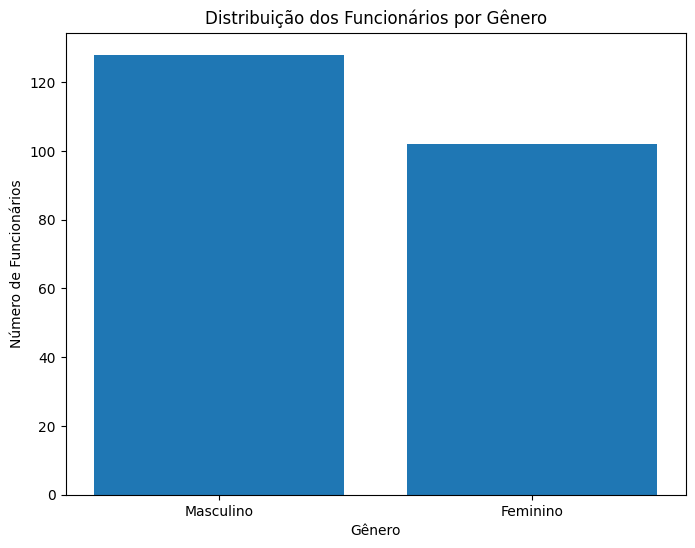

In [152]:
plt.figure(figsize=(8,6))
plt.bar(df['Gênero'].value_counts().index, df['Gênero'].value_counts())
plt.title("Distribuição dos Funcionários por Gênero")
plt.xlabel("Gênero") ## Descrição do eixo X
plt.ylabel("Número de Funcionários") ## Descrição do eixo Y
plt.show()

Temos, a partir do gráfico acima, que a dsitriubição dos fncionários por gênero é bem igualitária. Daí, podemos inferir que a cultura da empresa prioriza a igualdade de gênero ( pelo menos na distribuição dos funcionários / Ainda é necessário ver o sálario por gênero, para uma análise inicial mais precia )


## Distribuição dos funcionários em Home Office

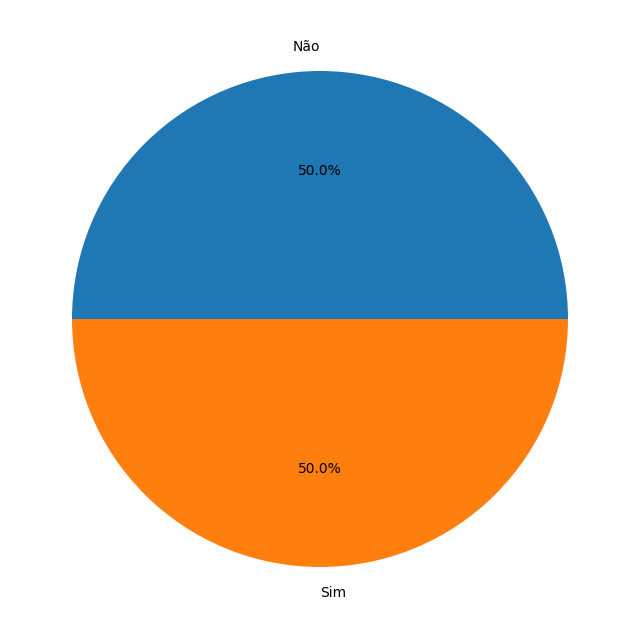

In [153]:
plt.figure(figsize=(8,16))
plt.pie(
  df['Home_Office'].value_counts(),
  labels=df['Home_Office'].value_counts().index,
  autopct='%1.1f%%'
)
plt.show()

Pelo Gráfico acima, interpretamos que a empresa permite um grande número de funcionários no regime online o que demostra o poder de se adaptar da companhia

## Distribuição de funcionários por produtividade

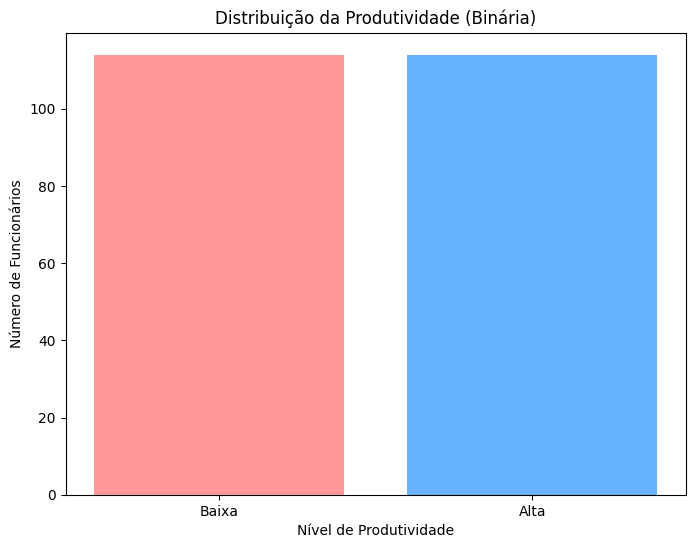

In [154]:
plt.figure(figsize=(8,6))
contagem_prod = df['Produtividade_bin'].value_counts().reindex(['Baixa', 'Alta'])
plt.bar(contagem_prod.index, contagem_prod.values, color=['#ff9999', '#66b3ff'])

plt.title("Distribuição da Produtividade (Binária)")
plt.xlabel("Nível de Produtividade")
plt.ylabel("Número de Funcionários")

plt.show()

Notamos que há um equilíbrio entre funcionários com baixa e alta produtividade. Porém, isso é, na verdade, uma consequência matemática direta da maneira como classificamos a produtividade anteriormente. Pois, ao definirmos a mediana como critério, é evidente que ela irá separar a amostra em duas metades.

# Item d
(d) Para variáveis quantitativas, utilize medidas descritivas e visualizações adequadas (como histogramas, boxplots, gráficos de dispersão ou gráficos de violino);

In [155]:
quantitativas = ['Idade', 'Salário', 'Horas_Trabalhadas', 'Produtividade', 'Satisfação','Tempo_Empresa', 'Cursos_Realizados']
tabela_descritiva = df[quantitativas].describe().round(2)

print("Medidas Descritivas das Variáveis Quantitativas:")
tabela_descritiva

Medidas Descritivas das Variáveis Quantitativas:


,Idade,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados
count,230.00,230.00,230.00,230.00,230.00,230.00,230.00
mean,30.55,8029.97,38.85,87.85,86.15,6.77,5.20
std,8.22,6556.33,5.82,12.24,12.06,5.96,4.22
min,18.00,2536.32,30.00,65.74,39.42,0.00,0.00
25%,24.00,2536.32,34.00,77.12,77.57,1.00,2.00
50%,29.00,5667.56,38.00,87.04,87.73,6.00,5.00
75%,35.00,12129.21,44.00,98.42,96.19,11.00,8.00
max,54.00,29052.82,48.00,112.06,100.00,30.00,20.00


## Análise de distribuição das varáveis quantitativas

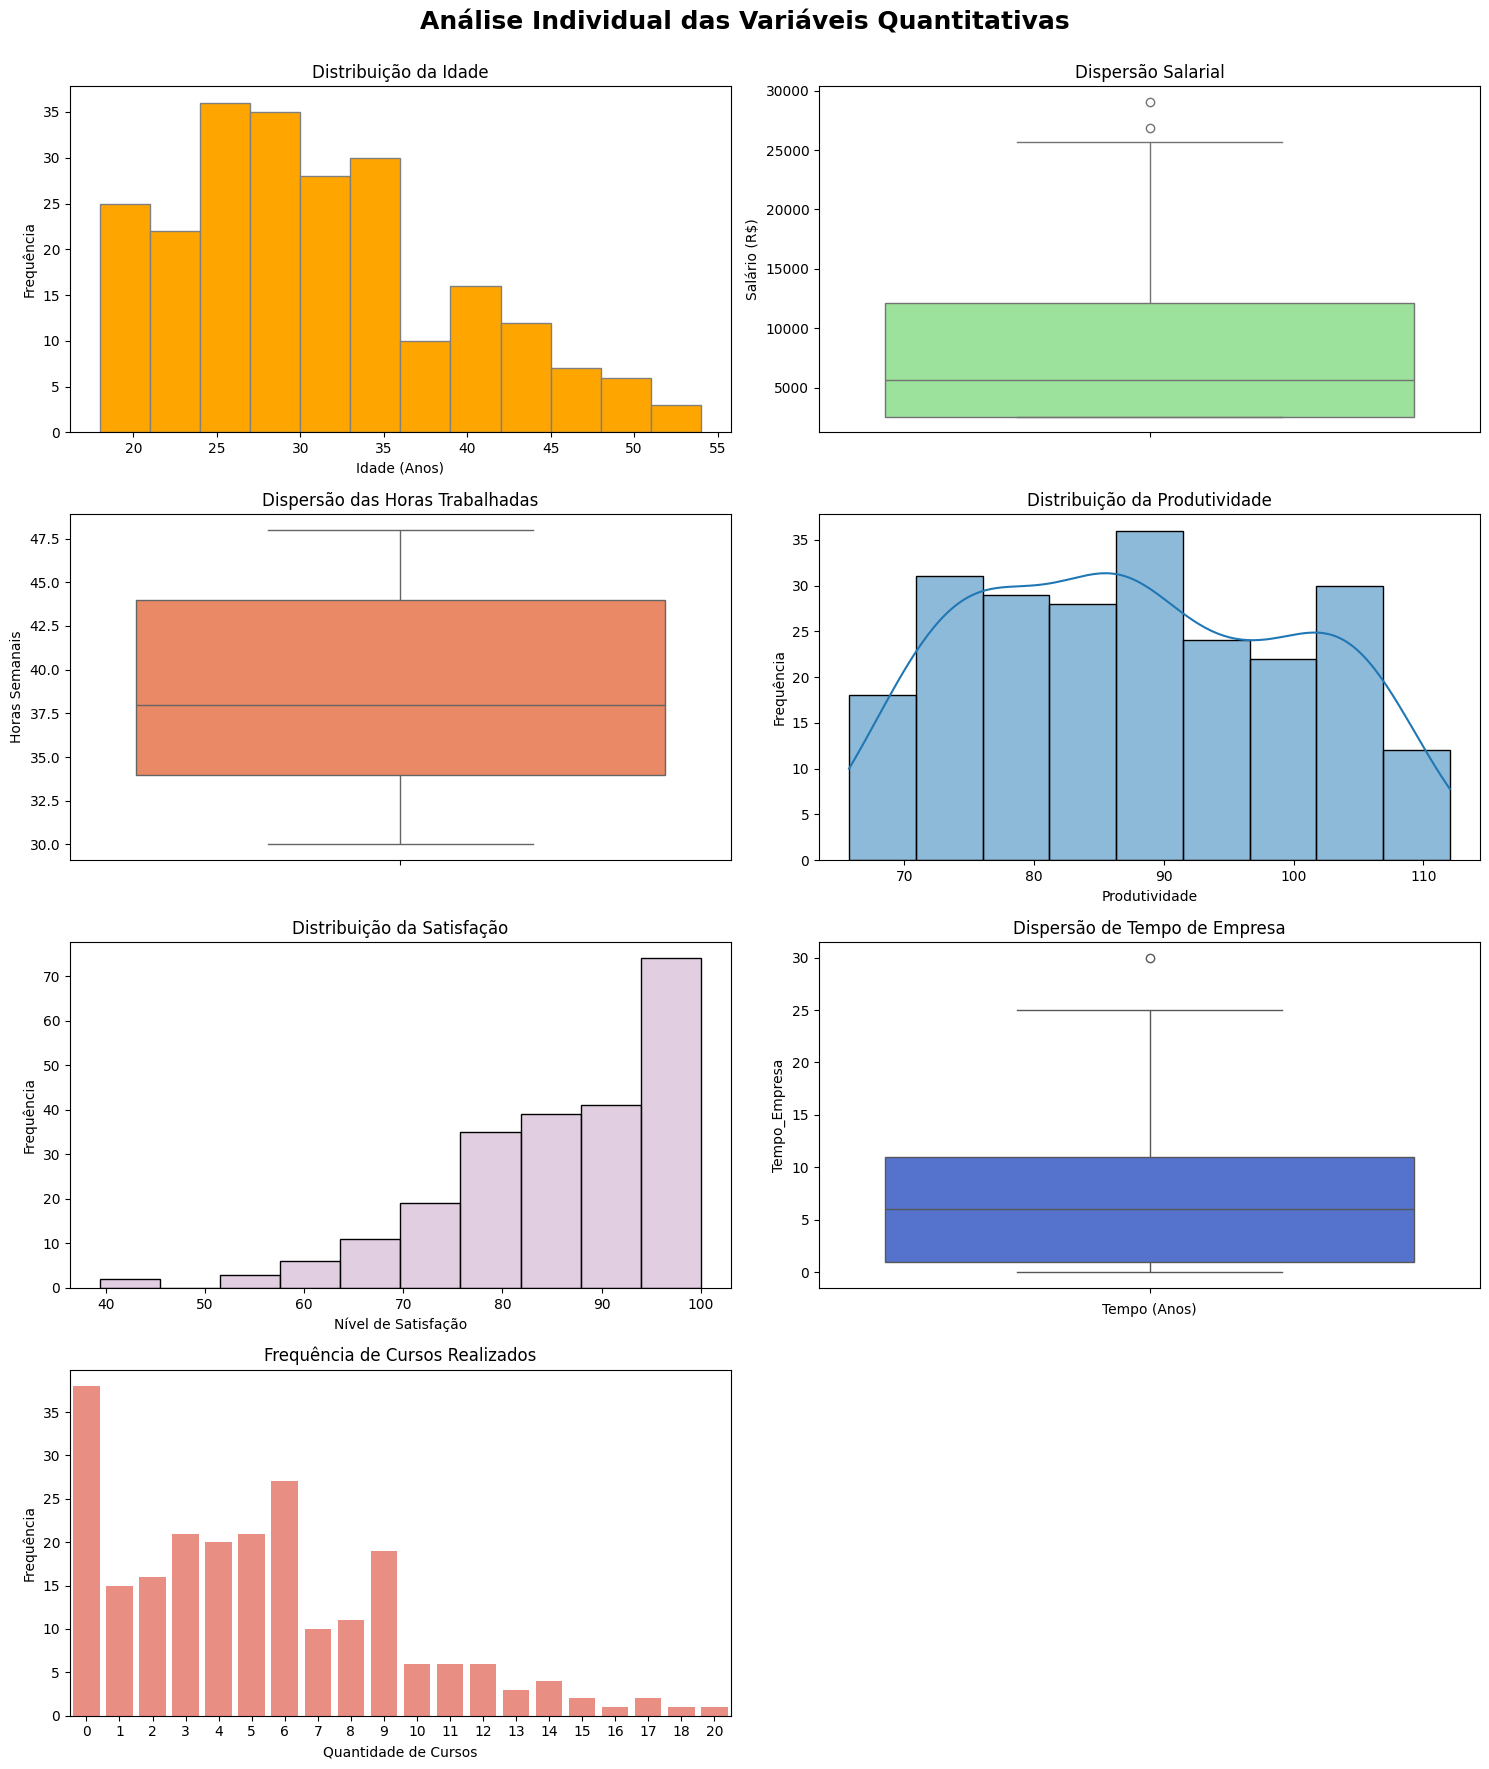

In [156]:
plt.figure(figsize=(15, 18))
plt.suptitle("Análise Individual das Variáveis Quantitativas", fontsize=18, fontweight='bold', y=0.98)

plt.subplot(4, 2, 1)
plt.hist(df['Idade'], bins=12, color='orange', edgecolor='gray')
plt.title('Distribuição da Idade', fontsize=12)
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')

plt.subplot(4, 2, 2)
sns.boxplot(data=df, y='Salário', color='lightgreen')
plt.title('Dispersão Salarial', fontsize=12)
plt.ylabel('Salário (R$)')

plt.subplot(4, 2, 3)
sns.boxplot(data=df, y='Horas_Trabalhadas', color='coral')
plt.title('Dispersão das Horas Trabalhadas', fontsize=12)
plt.ylabel('Horas Semanais')

plt.subplot(4, 2, 4)
sns.histplot(data=df, x='Produtividade', kde=True)
plt.title('Distribuição da Produtividade', fontsize=12,)
plt.xlabel('Produtividade')
plt.ylabel('Frequência')

plt.subplot(4, 2, 5)
sns.histplot(data=df, x='Satisfação', color = 'thistle')
plt.title('Distribuição da Satisfação', fontsize=12)
plt.xlabel('Nível de Satisfação')
plt.ylabel('Frequência')

plt.subplot(4, 2, 6)
sns.boxplot(data=df, y='Tempo_Empresa',color='royalblue')
plt.title('Dispersão de Tempo de Empresa')
plt.xlabel('Tempo (Anos)')

plt.subplot(4, 2, 7)
sns.countplot(data=df, x='Cursos_Realizados', color='salmon')
plt.title('Frequência de Cursos Realizados', fontsize=12)
plt.xlabel('Quantidade de Cursos')
plt.ylabel('Frequência')

plt.subplot(4, 2, 8).axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Análise das variáveis quantitativas
**1. Idade:** A empresa possui um perfil majoritariamente jovem, com média de idade próxima dos 30 anos mediana de 29 anos, o que significa que metade dos funcionários são mais jovens do que 29 anos.

**2. Salário:** Apresenta uma forte assimetria, com a mediana em torno dos R\$5.600, mas média de mais de R\$8.000, o que evidencia que, existe uma quantidade pequena de funcionários concentrando altas remunerações.

**3. Horas trabalhadas:** Mostra padronização, com média e mediana ambas próximas das 38 hotas. A ausência de outliers no boxplot evidencia que não há excessos nem grandes assimetrias nas cargas horárias.

**4. Produtividade:** Apresenta uma distribuição que se aproxima da normalidade. Alguns funcionários se destacam pela alta ou baixa produtividade, mas no geral, existe uma concentração em valores intermediários.

**5. Satisfação:** Maior concentração de funcionários nos níveis mais altos de satisfação. Apesar disso, existem alguns funcionários distoanto com níveis baixíssimos de satisfação, abaixo dos 40 pontos, o que exige atenção pontual.

**6. Tempo de Empresa:** Metade dos funcionários com até 6 anos de casa, o que é esperado tendo em vista a baixa idade média dos funcionários. Entretanto, existem excessões e outliers, com até 30 anos de permanência na empresa.

**7. Cursos Realizados:** Quantidade baixa de funcionários com grande número de cursos realizados, apesar disso, a média de 5 cursos por funcionário mostra que a qualificação depende do interesse individual dos funcionários.